# Importing Libraries
Here I am using 
- Numpy
- Pandas
- Matplotlib
- Scikit Learn

In [25]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from sklearn.ensemble import RandomForestRegressor
from sklearn.model_selection import train_test_split
from sklearn.metrics import mean_absolute_error, mean_squared_error, r2_score
from sklearn.model_selection import RandomizedSearchCV
from scipy.stats import randint
import math
import warnings

warnings.filterwarnings("ignore")

In [26]:
df = pd.read_csv("Clean_Dataset.csv")
df.head()

,Unnamed: 0,airline,flight,source_city,departure_time,stops,arrival_time,destination_city,class,duration,days_left,price
0,0,SpiceJet,SG-8709,Delhi,Evening,zero,Night,Mumbai,Economy,2.17,1,5953
1,1,SpiceJet,SG-8157,Delhi,Early_Morning,zero,Morning,Mumbai,Economy,2.33,1,5953
2,2,AirAsia,I5-764,Delhi,Early_Morning,zero,Early_Morning,Mumbai,Economy,2.17,1,5956
3,3,Vistara,UK-995,Delhi,Morning,zero,Afternoon,Mumbai,Economy,2.25,1,5955
4,4,Vistara,UK-963,Delhi,Morning,zero,Morning,Mumbai,Economy,2.33,1,5955


In [27]:
df["airline"].value_counts() # so we can use here one hot encoding because its limited number of flights here

airline
Vistara      127859
Air_India     80892
Indigo        43120
GO_FIRST      23173
AirAsia       16098
SpiceJet       9011
Name: count, dtype: int64

In [28]:
df.source_city.value_counts() # same for this also one hot encoding

source_city
Delhi        61343
Mumbai       60896
Bangalore    52061
Kolkata      46347
Hyderabad    40806
Chennai      38700
Name: count, dtype: int64

In [29]:
df.departure_time.value_counts() # one hot encoding

departure_time
Morning          71146
Early_Morning    66790
Evening          65102
Night            48015
Afternoon        47794
Late_Night        1306
Name: count, dtype: int64

In [30]:
df["class"].value_counts() # binary encoding here i will do

class
Economy     206666
Business     93487
Name: count, dtype: int64

In [31]:
df.stops.value_counts()

stops
one            250863
zero            36004
two_or_more     13286
Name: count, dtype: int64

In [32]:
df.duration.min()

np.float64(0.83)

In [33]:
df.duration.max()

np.float64(49.83)

In [34]:
df.duration.median()

np.float64(11.25)

# Data Preprocessing
- Removing unnamed and flight column
- OneHot encoding on Airline Column, source_city, destination_city, departure_time, arrival_time, stops
- duration,	days_left,	price leave these columns as it is.

In [35]:
df = df.drop("Unnamed: 0", axis = 1)
df = df.drop("flight", axis = 1)

In [36]:
df["class"] = df["class"].apply(lambda x: 1 if x == "Economy" else 0 )

df["stops"] = pd.factorize(df.stops)[0]

In [37]:
df["stops"] = pd.factorize(df.stops)[0]

df = df.join(pd.get_dummies(df.airline, prefix = "airline")).drop("airline", axis = 1)
df = df.join(pd.get_dummies(df.source_city, prefix = "city")).drop("source_city", axis = 1)
df = df.join(pd.get_dummies(df.departure_time, prefix = "departure")).drop("departure_time", axis = 1)
df = df.join(pd.get_dummies(df.arrival_time, prefix = "arrival")).drop("arrival_time", axis = 1)
df = df.join(pd.get_dummies(df.destination_city, prefix = "destination")).drop("destination_city", axis = 1)

In [38]:
df

,stops,class,duration,days_left,price,airline_AirAsia,airline_Air_India,airline_GO_FIRST,airline_Indigo,airline_SpiceJet,...,arrival_Evening,arrival_Late_Night,arrival_Morning,arrival_Night,destination_Bangalore,destination_Chennai,destination_Delhi,destination_Hyderabad,destination_Kolkata,destination_Mumbai
0,0,1,2.17,1,5953,False,False,False,False,True,...,False,False,False,True,False,False,False,False,False,True
1,0,1,2.33,1,5953,False,False,False,False,True,...,False,False,True,False,False,False,False,False,False,True
2,0,1,2.17,1,5956,True,False,False,False,False,...,False,False,False,False,False,False,False,False,False,True
3,0,1,2.25,1,5955,False,False,False,False,False,...,False,False,False,False,False,False,False,False,False,True
4,0,1,2.33,1,5955,False,False,False,False,False,...,False,False,True,False,False,False,False,False,False,True
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
300148,1,0,10.08,49,69265,False,False,False,False,False,...,True,False,False,False,False,False,False,True,False,False
300149,1,0,10.42,49,77105,False,False,False,False,False,...,False,False,False,True,False,False,False,True,False,False
300150,1,0,13.83,49,79099,False,False,False,False,False,...,False,False,False,True,False,False,False,True,False,False
300151,1,0,10.00,49,81585,False,False,False,False,False,...,True,False,False,False,False,False,False,True,False,False


# Training Regression Model

In [39]:
X, y = df.drop("price", axis = 1), df["price"]
print(y)

0          5953
1          5953
2          5956
3          5955
4          5955
          ...  
300148    69265
300149    77105
300150    79099
300151    81585
300152    81585
Name: price, Length: 300153, dtype: int64


In [40]:
X_train, X_test, y_train, y_test = train_test_split(X, y, train_size = 0.8)

In [41]:
rf = RandomForestRegressor(n_jobs = -1) # trains tress in parallel accross all CPU cores

rf.fit(X_train, y_train)


,"n_jobs n_jobs: int, default=NoneThe number of jobs to run in parallel. :meth:`fit`, :meth:`predict`,:meth:`decision_path` and :meth:`apply` are all parallelized over thetrees. ``None`` means 1 unless in a :obj:`joblib.parallel_backend`context. ``-1`` means using all processors. See :term:`Glossary<n_jobs>` for more details.",-1
,"n_estimators n_estimators: int, default=100The number of trees in the forest... versionchanged:: 0.22 The default value of ``n_estimators`` changed from 10 to 100 in 0.22.",100
,"criterion criterion: {""squared_error"", ""absolute_error"", ""poisson""}, default=""squared_error""The function to measure the quality of a split. Supported criteriaare ""squared_error"" for the mean squared error, which is equal tovariance reduction as feature selection criterion and minimizes the L2loss using the mean of each terminal node, ""absolute_error"" for the meanabsolute error, which minimizes the L1 loss using the median of each terminalnode, and ""poisson"" which uses reduction in Poisson deviance to find splits,also using the mean of each terminal node... versionadded:: 0.18 Mean Absolute Error (MAE) criterion... versionadded:: 1.0 Poisson criterion... versionchanged:: 1.9 Criterion `""friedman_mse""` was deprecated.",'squared_error'
,"max_depth max_depth: int, default=NoneThe maximum depth of the tree. If None, then nodes are expanded untilall leaves are pure or until all leaves contain less thanmin_samples_split samples.",None
,"min_samples_split min_samples_split: int or float, default=2The minimum number of samples required to split an internal node:- If int, then consider `min_samples_split` as the minimum number.- If float, then `min_samples_split` is a fraction and `ceil(min_samples_split * n_samples)` are the minimum number of samples for each split... versionchanged:: 0.18 Added float values for fractions.",2
,"min_samples_leaf min_samples_leaf: int or float, default=1The minimum number of samples required to be at a leaf node.A split point at any depth will only be considered if it leaves atleast ``min_samples_leaf`` training samples in each of the left andright branches. This may have the effect of smoothing the model,especially in regression.- If int, then consider `min_samples_leaf` as the minimum number.- If float, then `min_samples_leaf` is a fraction and `ceil(min_samples_leaf * n_samples)` are the minimum number of samples for each node... versionchanged:: 0.18 Added float values for fractions.",1
,"min_weight_fraction_leaf min_weight_fraction_leaf: float, default=0.0The minimum weighted fraction of the sum total of weights (of allthe input samples) required to be at a leaf node. Samples haveequal weight when sample_weight is not provided.",0.0
,"max_features max_features: {""sqrt"", ""log2"", None}, int or float, default=1.0The number of features to consider when looking for the best split:- If int, then consider `max_features` features at each split.- If float, then `max_features` is a fraction and `max(1, int(max_features * n_features_in_))` features are considered at each split.- If ""sqrt"", then `max_features=sqrt(n_features)`.- If ""log2"", then `max_features=log2(n_features)`.- If None or 1.0, then `max_features=n_features`... note:: The default of 1.0 is equivalent to bagged trees and more randomness can be achieved by setting smaller values, e.g. 0.3... versionchanged:: 1.1 The default of `max_features` changed from `""auto""` to 1.0.Note: the search for a split does not stop until at least onevalid partition of the node samples is found, even if it requires toeffectively inspect more than ``max_features`` features.",1.0
,"max_leaf_nodes max_leaf_nodes: int, default=NoneGrow trees with ``max_leaf_nodes`` in best-first fashion.Best nodes are defined as relative reduction in impurity.If None then unlimited number of leaf nodes.",None
,"min_impurity_decrease min_impurity_decrease: float, default=0.0A node will be split if this split induces a decrease of the impuritygreater than or equ

In [42]:
rf.score(X_test, y_test)


0.9851741642404155

In [43]:

y_pred = rf.predict(X_test)
print(f'R2 Score: {r2_score(y_test, y_pred)}')
print(f'MAE: {mean_absolute_error(y_test, y_pred)}')
print(f'MSE: {mean_squared_error(y_test, y_pred)}')
print(f'RMSE: {math.sqrt(mean_squared_error(y_test, y_pred))}')

R2 Score: 0.9851741642404155
MAE: 1076.1052601686881
MSE: 7649856.783738789
RMSE: 2765.837447092433


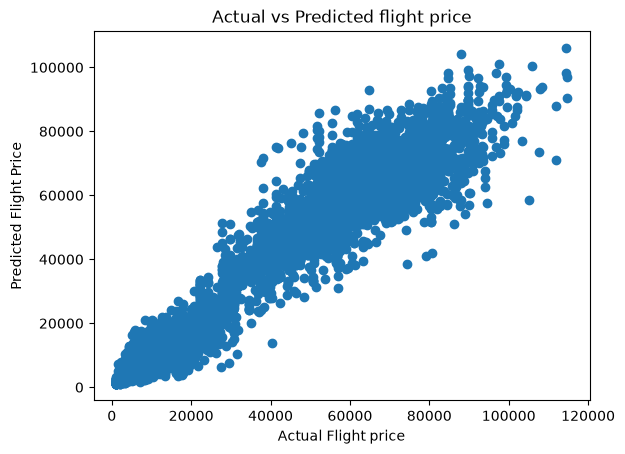

In [44]:
plt.scatter(y_test, y_pred)
plt.xlabel("Actual Flight price")
plt.ylabel("Predicted Flight Price")
plt.title("Actual vs Predicted flight price")
plt.show()

In [45]:
df.price.describe()

count    300153.000000
mean      20889.660523
std       22697.767366
min        1105.000000
25%        4783.000000
50%        7425.000000
75%       42521.000000
max      123071.000000
Name: price, dtype: float64

In [46]:
# Important features
importances = dict(zip(rf.feature_names_in_, rf.feature_importances_))
sorted_importances = sorted(importances.items(), key = lambda x: x[1], reverse = True)
sorted_importances

[('class', np.float64(0.8801606997409898)),
 ('duration', np.float64(0.05721392476962191)),
 ('days_left', np.float64(0.01857868478718318)),
 ('airline_Air_India', np.float64(0.005000066343087158)),
 ('airline_Vistara', np.float64(0.004870675195012898)),
 ('city_Delhi', np.float64(0.0039003586381374084)),
 ('destination_Delhi', np.float64(0.003590314146198797)),
 ('city_Mumbai', np.float64(0.0022210610284079425)),
 ('destination_Mumbai', np.float64(0.0019885178767700316)),
 ('stops', np.float64(0.001815283951860663)),
 ('destination_Kolkata', np.float64(0.0017365627736381805)),
 ('city_Kolkata', np.float64(0.0017224941553428176)),
 ('arrival_Evening', np.float64(0.0015265719430109018)),
 ('destination_Hyderabad', np.float64(0.0015242004987865991)),
 ('city_Hyderabad', np.float64(0.0012246828943218654)),
 ('destination_Bangalore', np.float64(0.0011833459402091097)),
 ('arrival_Night', np.float64(0.001165722105715209)),
 ('departure_Evening', np.float64(0.0011010638971380657)),
 ('city_B

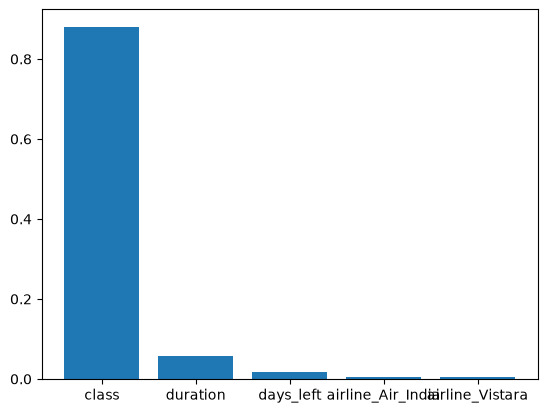

In [47]:
plt.Figure(figsize = (10, 6))
plt.bar([x[0] for x in sorted_importances[:5]], [x[1] for x in sorted_importances[:5]])
plt.show()

# Hyperparameter Tuning

In [48]:

rf = RandomForestRegressor(n_jobs = -1)
parms_dist = {
    "n_estimators": randint(50, 500),
    "max_depth": [None, 10, 20, 30, 40, 50],
    "max_features":  [1, "sqrt", "log2", 0.3, 0.5],
    "min_samples_leaf": randint(1, 10),
    "min_samples_split": randint(2, 20)

}
random_search = RandomizedSearchCV(estimator = rf, param_distributions = parms_dist, n_iter = 2, cv = 3, random_state = 45, 
                                   verbose = 2, n_jobs = -1, scoring = "neg_mean_squared_error"  )
random_search.fit(X_train, y_train)
best_regressor= random_search.best_estimator_


Fitting 3 folds for each of 2 candidates, totalling 6 fits
[CV] END max_depth=10, max_features=1, min_samples_leaf=2, min_samples_split=16, n_estimators=359; total time=  34.4s
[CV] END max_depth=10, max_features=1, min_samples_leaf=2, min_samples_split=16, n_estimators=359; total time=  36.3s
[CV] END max_depth=10, max_features=1, min_samples_leaf=2, min_samples_split=16, n_estimators=359; total time=  36.5s
[CV] END max_depth=30, max_features=0.3, min_samples_leaf=1, min_samples_split=5, n_estimators=118; total time=  41.1s
[CV] END max_depth=30, max_features=0.3, min_samples_leaf=1, min_samples_split=5, n_estimators=118; total time=  42.7s
[CV] END max_depth=30, max_features=0.3, min_samples_leaf=1, min_samples_split=5, n_estimators=118; total time=  42.8s


In [49]:
best_regressor.score(X_test, y_test)

0.9857071203841582

In [50]:
y_pred = best_regressor.predict(X_test)
print(f'R2 Score: {r2_score(y_test, y_pred)}')
print(f'MAE: {mean_absolute_error(y_test, y_pred)}')
print(f'MSE: {mean_squared_error(y_test, y_pred)}')
print(f'RMSE: {math.sqrt(mean_squared_error(y_test, y_pred))}')

R2 Score: 0.9857071203841582
MAE: 1169.6823407493762
MSE: 7374861.280095071
RMSE: 2715.669582275257
